## Netflix - Data Exploration and Visualisation

In [64]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

### Reading File

In [198]:
df = pd.read_csv('./data/netflix.csv')
df_original = df.copy()

In [199]:
df.head() # Show the first 5 records

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning

In [67]:
df.shape

(8807, 12)

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [69]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Statistical Summary of categorical type data

In [71]:
df.describe(include='object')

C:\Users\manth\AppData\Local\Temp\ipykernel_12520\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


### Checking for missing values

In [72]:
df.isnull().sum()  # Count all Null values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [22]:
missing_values_percentage = (df.isnull().mean() * 100).round(2)  # Caluclate the missing percentage
print(missing_values_percentage)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


### Handling null values

In [200]:
# Handling null values for categorial variables
catergorial_colums = ['cast', 'director', 'country', 'rating']
for col in catergorial_colums:
    df[col] = df[col].fillna('Unknown_' + col)

In [ ]:
# Handling null values in duration 
df['duration'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration'] = df['duration'].fillna(0)

In [94]:
# Display the count of missing values for each column
df.isnull().sum()

show_id             0
type                0
title               0
director        21937
cast             1190
country          5421
date_added         69
release_year        0
rating             38
duration            0
listed_in           0
description         0
dtype: int64

In [96]:
df.isnull().sum()

show_id             0
type                0
title               0
director        21937
cast             1190
country          5421
date_added         69
release_year        0
rating             38
duration            0
listed_in           0
description         0
dtype: int64

### Unnesting columns

In [201]:
# Unnesting "cast" column
df['cast'] = df['cast'].str.split(', ')
df = df.explode('cast')

# Unnesting 'director" column
df['director'] = df['director'].str.split(', ')
df = df.explode('director')

# Unnesting 'country' column
df['country'] = df['country'].str.split(', ')
df = df.explode('country')

In [98]:
df.describe(include='object')

C:\Users\manth\AppData\Local\Temp\ipykernel_12520\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,listed_in,description
count,89382,89382,89382,67445,88192,83961,89313,89344,89382,89382
unique,8807,2,8807,4993,36439,127,1767,17,514,8775
top,s7516,Movie,Movie 43,Martin Scorsese,Alfred Molina,United States,"January 1, 2020",TV-MA,"Dramas, International Movies",An eye-popping cast stars in this sketch-comed...
freq,468,65346,468,217,85,30471,1744,29860,4255,468


### Convert categorical attributes to 'category' data type

In [202]:
# Converting the columns 'type', 'country', and 'rating' in the dataframe 'df' to the 'category' data type
df['type'] = df['type'].astype('category')
df['country'] = df['country'].astype('category')
df['rating'] = df['rating'].astype('category')

In [101]:
df.info()

<class 'pandas.DataFrame'>
Index: 89382 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       89382 non-null  str     
 1   type          89382 non-null  category
 2   title         89382 non-null  str     
 3   director      67445 non-null  str     
 4   cast          88192 non-null  str     
 5   country       83961 non-null  category
 6   date_added    89313 non-null  str     
 7   release_year  89382 non-null  int64   
 8   rating        89344 non-null  category
 9   duration      89382 non-null  float64 
 10  listed_in     89382 non-null  str     
 11  description   89382 non-null  str     
dtypes: category(3), float64(1), int64(1), str(7)
memory usage: 7.2 MB


### Convert date and time attributes to 'date_time' data type

In [203]:
# Convert 'date_added' column to datetime data type
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
df['duration'] = df['duration'].astype(int)
df['duration'].dtype

## Data Analysis

### (Q1) Find the counts of each categorical variable both using graphical and non-graphical analysis.

In [112]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Thabang Molaba,South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


#### 1. Non-graphical

In [114]:
# Catogorical variables to analyze
catergorial_colums = ['type', 'country', 'rating']

for col in catergorial_colums:
    print(f"\nColumn : {col}")
    print(df[col].value_counts())


Column : type
type
Movie      65346
TV Show    24036
Name: count, dtype: int64

Column : country
country
United States     30471
India              8537
United Kingdom     5713
Canada             3946
Japan              3758
                  ...  
Samoa                 1
Sri Lanka             1
Uganda                1
United States,        1
Vatican City          1
Name: count, Length: 127, dtype: int64

Column : rating
rating
TV-MA       29860
TV-14       17437
R           12865
PG-13        7814
TV-PG        6356
PG           5182
TV-Y7        4073
TV-Y         2745
TV-G         1329
G             878
NR            676
NC-17          55
TV-Y7-FV       39
UR             32
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


#### 2. Graphical -> Showing bar char

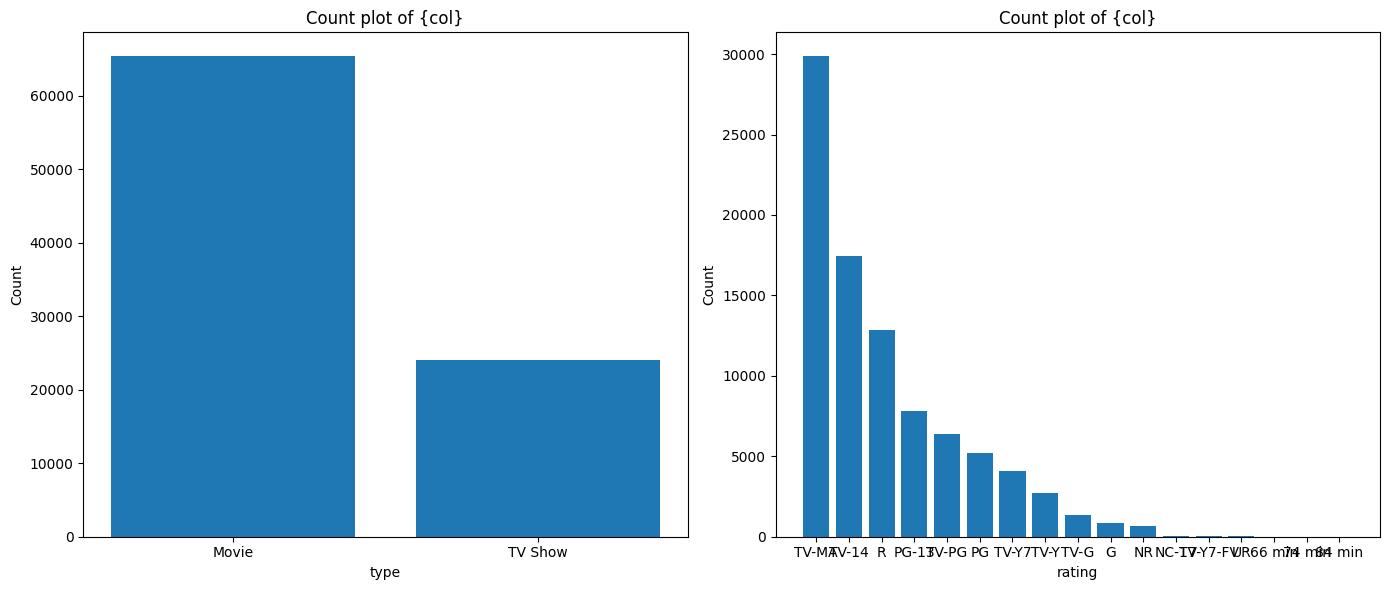

In [119]:
# Catogorical variables to analyze
catergorial_colums = ['type','rating']

# Create subplots
fig, ax = plt.subplots(1, len(catergorial_colums), figsize=(14,6))

# Loop through columns
for i, col in enumerate(catergorial_colums):
    counts = df[col].value_counts()

    ax[i].bar(counts.index, counts.values)

    ax[i].set_title('Count plot of {col}')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')

    

plt.tight_layout()
plt.savefig("./outputs/categorical_analysis.png")
plt.show()

### Q2) How has the number of movies released per year changed over the last 20-30 years?

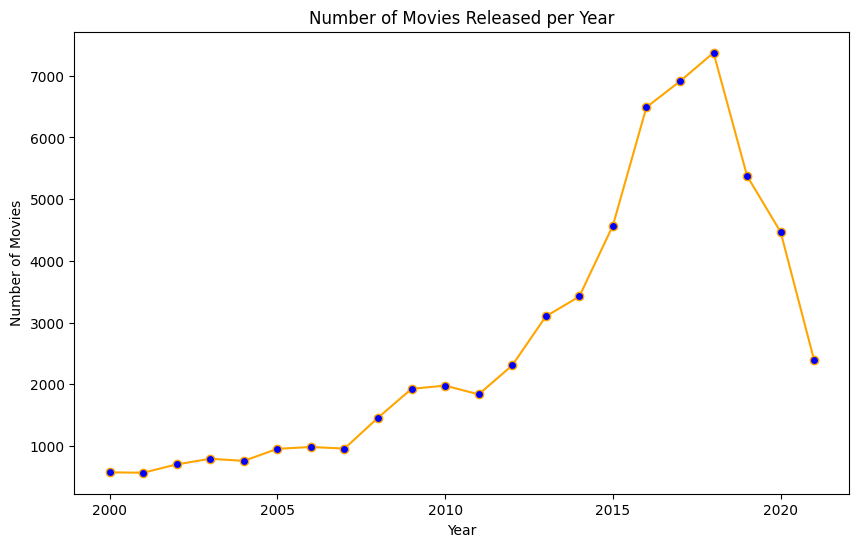

In [130]:
movies = df[df.type == 'Movie']

movies_per_year = movies['release_year'].value_counts().sort_index()
movies_per_year = movies_per_year[movies_per_year.index >= 2000]

plt.figure(figsize=(10, 6))
plt.plot(movies_per_year.index, movies_per_year.values, color='orange', marker='o', markerfacecolor='blue')

plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.savefig('./outputs/Number of Movies Released per Year.png', dpi=300, bbox_inches='tight')
plt.show()



### Comparison of TV shows vs. Movies

In [132]:
movies_df = df[df.type == 'Movie']
tv_shows_df = df[df.type == 'TV Show']


In [133]:
# Group and unique movie titles for each country
movie_counts_by_country = movies_df.groupby('country')['title'].nunique().reset_index()
movie_counts_by_country = movie_counts_by_country.sort_values(by='title', ascending=False)

# Select top 10 countries with the most movies
top_10_movie_countries = movie_counts_by_country.head(10)
print("Top 10 countries with the most Movies:\n")
print(top_10_movie_countries)

Top 10 countries with the most Movies:

            country  title
114   United States   2751
43            India    962
112  United Kingdom    532
20           Canada    319
34           France    303
36          Germany    182
100           Spain    171
51            Japan    119
23            China    114
65           Mexico    111


In [134]:
# Group and count unique TV show titles for each country
tv_show_counts_by_country = tv_shows_df.groupby('country')['title'].nunique().reset_index()
tv_show_counts_by_country = tv_show_counts_by_country.sort_values(by='title', ascending=False)

# Select top 10 countries with the most TV shows
top_10_tv_show_countries = tv_show_counts_by_country.head(10)
print("Top 10 countries with the most TV shows:\n")
print(top_10_tv_show_countries)

Top 10 countries with the most TV shows:

           country  title
63   United States    938
62  United Kingdom    272
30           Japan    199
52     South Korea    170
8           Canada    126
19          France     90
25           India     84
57          Taiwan     70
2        Australia     66
53           Spain     61


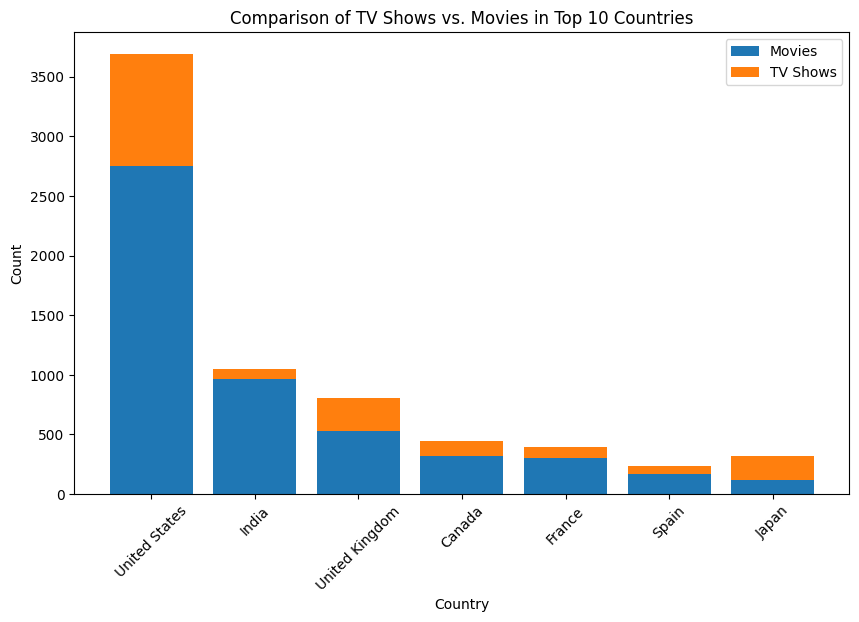

In [151]:
top_countries_data = pd.merge(
    top_10_movie_countries,
    top_10_tv_show_countries,
    on='country',
    suffixes=('_Movies', '_TV_Shows')   
)

plt.figure(figsize=(10, 6))

# Movies
plt.bar(
    top_countries_data['country'],
    top_countries_data['title_Movies'],
    label='Movies'
)

# TV Shows (stacked)
plt.bar(
    top_countries_data['country'],
    top_countries_data['title_TV_Shows'],
    bottom=top_countries_data['title_Movies'],  # ✅ important
    label='TV Shows'
)

plt.title('Comparison of TV Shows vs. Movies in Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()

plt.savefig('./outputs/Comparison of TV Shows vs. Movies in Top 10 Countries.png', dpi=300, bbox_inches='tight')
plt.show()

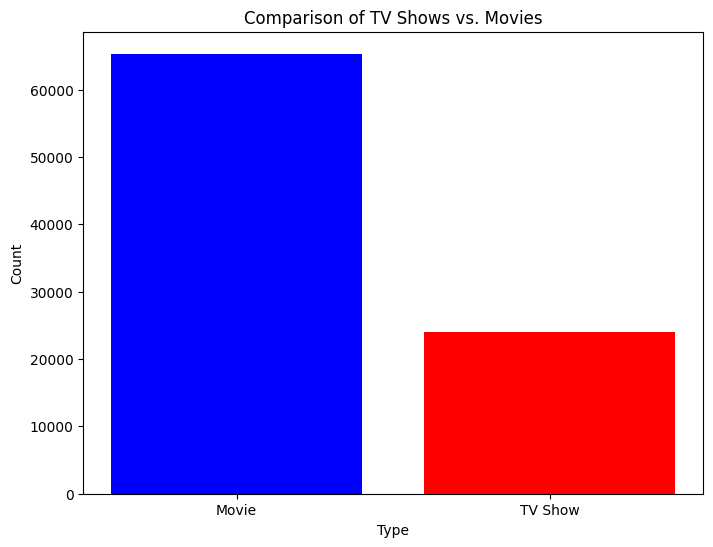

In [145]:
# Count values
counts = df['type'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values, color=['blue', 'red'])


plt.title('Comparison of TV Shows vs. Movies')
plt.xlabel('Type')
plt.ylabel('Count')

plt.savefig('./outputs/Comparison of TV Shows vs. Movies.png', dpi=300, bbox_inches='tight')
plt.show()

### Q5) Does the duration of content vary based on ratings, and how does it differ between TV shows and Movies?

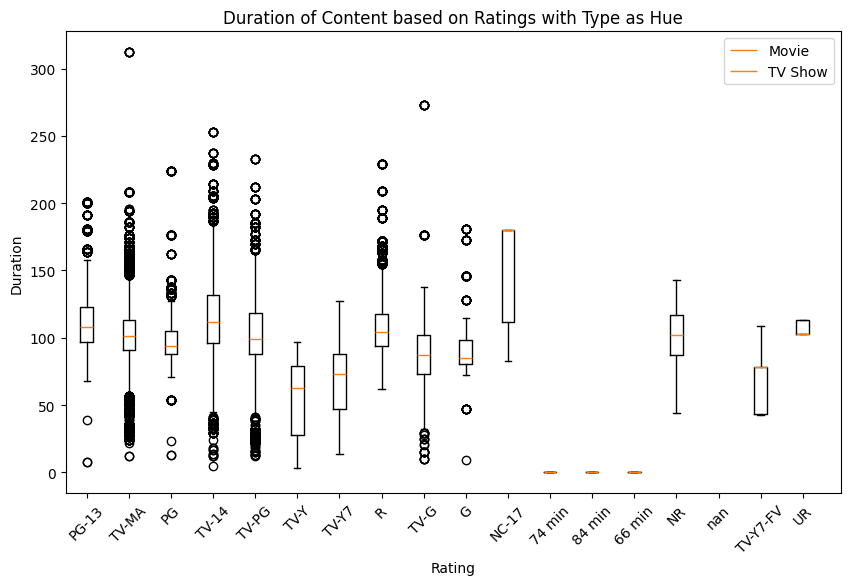

In [158]:
movies = df[df['type'] == 'Movie']
tv_shows = df[df.type == 'TV Shows']

ratings = df['rating'].unique()
movies_data = [movies[movies['rating'] == r]['duration'] for r in ratings]

tv_data = [tv_shows[tv_shows['rating'] == r]['duration'] for r in ratings]

plt.figure(figsize=(10, 6))

plt.boxplot(movies_data, positions=range(len(ratings)), widths=0.3, label='Movie')
plt.boxplot(tv_data, positions=[i + 0.4 for i in range(len(ratings))], widths=0.3, label='TV Show')

plt.xticks(range(len(ratings)), ratings, rotation=45)
plt.title('Duration of Content based on Ratings with Type as Hue')
plt.xlabel('Rating')
plt.ylabel('Duration')
plt.legend()


plt.savefig('./outputs/Duration of Content based on Ratings with Type as Hue.png', dpi=300, bbox_inches='tight')
plt.show()




**Observation:**

* The **box plot** shows the distribution of content duration based on ratings, with 'type' (TV Show or Movie) as a hue. It provides insights into how the **duration of content** varies for **different ratings** and between **TV shows and movies**.
* The **box plot** reveals that **TV shows** typically have a **higher duration** than **movies** for all **ratings**. The **median duration** of **TV shows** is **generally longer** than the **median duration** of **movies**, as indicated by the position of the box plots.

### **(Q6) What is the best time to launch a TV show?**

To find the best time to launch a TV show or a movie, we will analyze the data separately for TV shows and movies to determine the best week and the best month for release. We will create new columns for week and month, then group the data accordingly to count the total number of TV shows and movies released in each week and each month.



In [159]:
df['date_added']

0      2021-09-25
1      2021-09-24
1      2021-09-24
1      2021-09-24
1      2021-09-24
          ...    
8806   2019-03-02
8806   2019-03-02
8806   2019-03-02
8806   2019-03-02
8806   2019-03-02
Name: date_added, Length: 89382, dtype: datetime64[us]

In [161]:
# Extract the week and month from the 'date_added' column
df['Week'] = df['date_added'].dt.isocalendar().week
df['Month'] = df['date_added'].dt.month

In [180]:
# Filter TV shows
tv_shows_df = df[df.type == 'TV Show']

# Group and count TV shows by week
tv_shows_by_week = tv_shows_df.groupby('Week')['title'].count().reset_index()
tv_shows_by_week = tv_shows_by_week.sort_values(by='Week', ascending=False)

# Group and count Tv shows by week
tv_shows_by_month = tv_shows_df.groupby('Month')['title'].count().reset_index()
tv_shows_by_month = tv_shows_by_month.sort_values(by='Month', ascending=False)



In [181]:
# Best week to launch a TV show
best_week = tv_shows_by_week['Week'].iloc[0]

# Best month to launch a TV show
best_month = tv_shows_by_month['Month'].iloc[0]

In [182]:
print(f"The best week to launch a TV show is Week {best_week}")
print(f"The best month to launch a TV show is Month {best_month}")

The best week to launch a TV show is Week 53
The best month to launch a TV show is Month 12.0


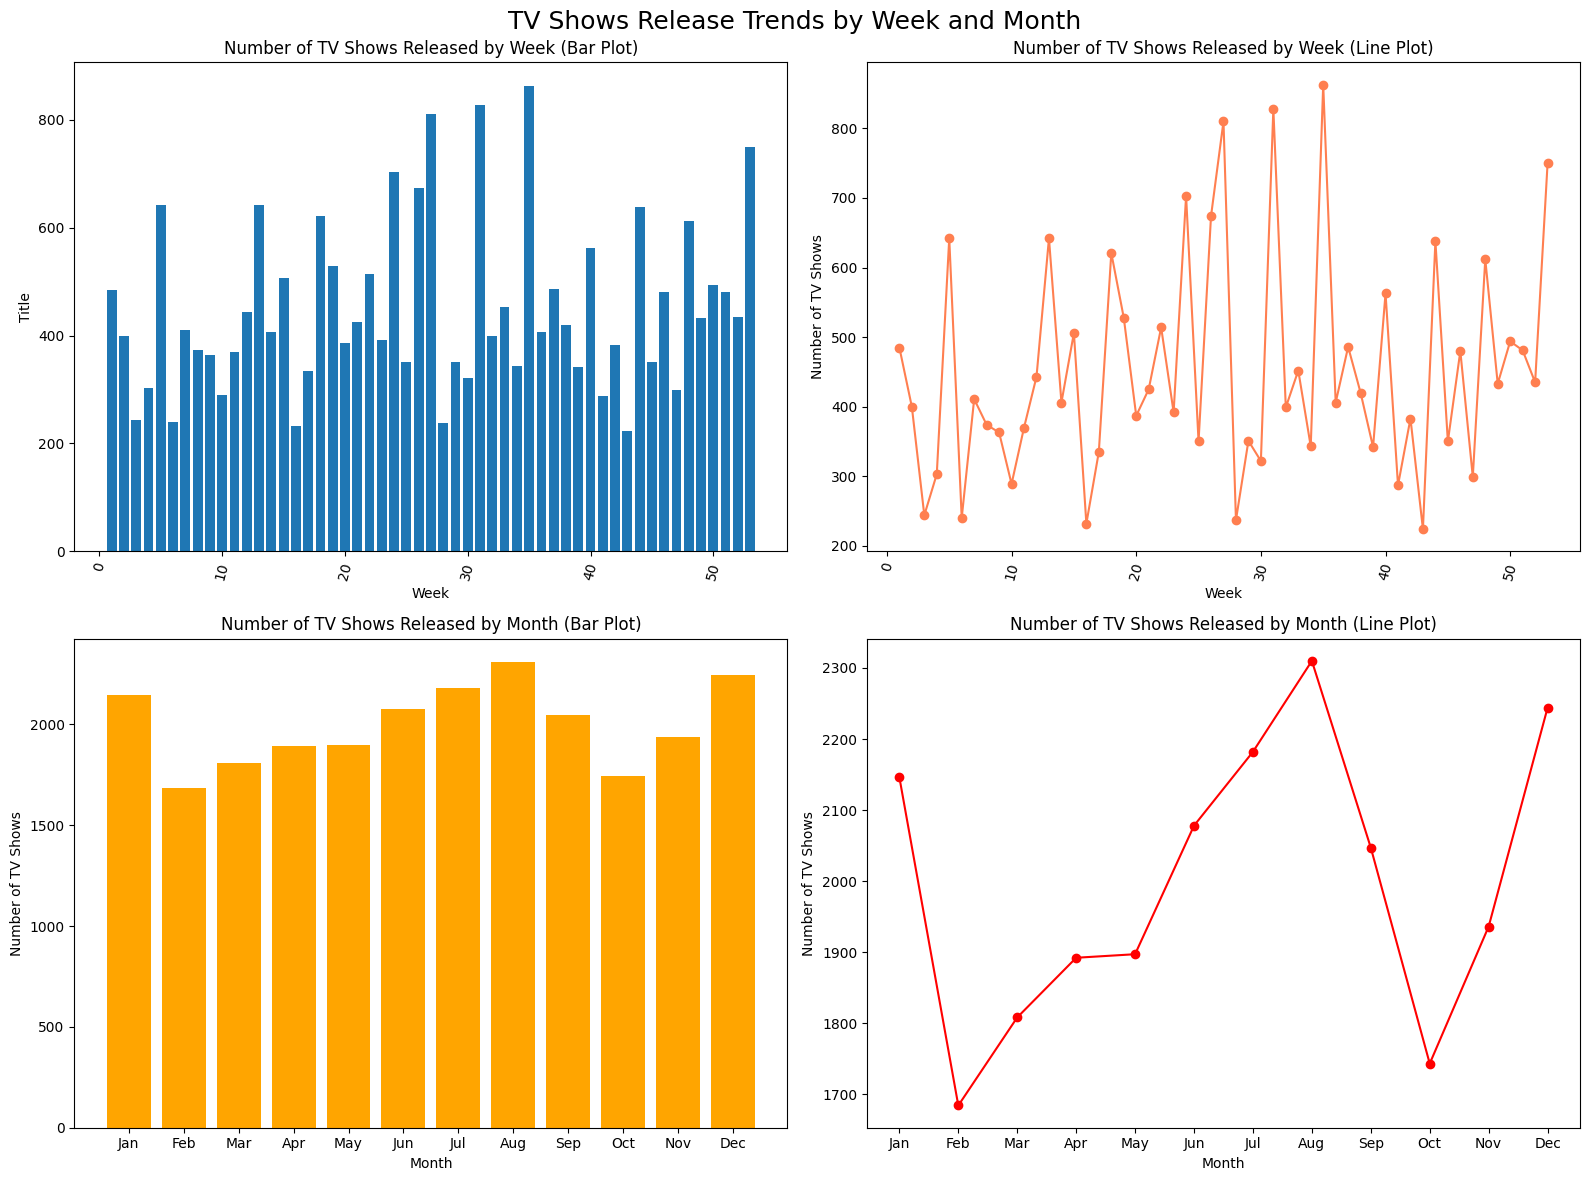

In [ ]:
# Create all graphs into one
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Week - Barplot of TV Shows
axs[0,0].bar(tv_shows_by_week['Week'], tv_shows_by_week['title'])
axs[0,0].set_title("Number of TV Shows Released by Week (Bar Plot)")
axs[0,0].set_xlabel('Week')
axs[0,0].set_ylabel('Title')
axs[0,0].tick_params(axis='x', rotation=75)

# 🔹 2. Week - Line (Point Plot Equivalent)
axs[0, 1].plot(
    tv_shows_by_week['Week'],
    tv_shows_by_week['title'],
    marker='o',
    color='coral'
)
axs[0, 1].set_title('Number of TV Shows Released by Week (Line Plot)')
axs[0, 1].set_xlabel('Week')
axs[0, 1].set_ylabel('Number of TV Shows')
axs[0, 1].tick_params(axis='x', rotation=75)

# 🔹 3. Month - Bar Plot
axs[1, 0].bar(tv_shows_by_month['Month'], tv_shows_by_month['title'], color='orange')
axs[1, 0].set_title('Number of TV Shows Released by Month (Bar Plot)')
axs[1, 0].set_xlabel('Month')
axs[1, 0].set_ylabel('Number of TV Shows')

# Month labels
axs[1, 0].set_xticks(range(1, 13))
axs[1, 0].set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

# 🔹 4. Month - Line Plot
axs[1, 1].plot(
    tv_shows_by_month['Month'],
    tv_shows_by_month['title'],
    marker='o',
    color='red'
)
axs[1, 1].set_title('Number of TV Shows Released by Month (Line Plot)')
axs[1, 1].set_xlabel('Month')
axs[1, 1].set_ylabel('Number of TV Shows')

# Month labels
axs[1, 1].set_xticks(range(1, 13))
axs[1, 1].set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

fig.suptitle("TV Shows Release Trends by Week and Month", fontsize=18)

plt.tight_layout()
plt.savefig('./outputs/TV Shows Release Trends by Week and Month.png', dpi=300, bbox_inches='tight')
plt.show()


**Observations:**

Based on the **bar plots** and **point plots**, we can make the following observations:

* The code identifies the **week with the highest number of TV show releases**, labeled as **"best_week"**. This **week** is displayed in both the **bar plot** and **point plot** for **TV shows released by week**.
* The code also identifies the **month with the highest number of TV show releases**, labeled as **"best_month"**. This **month** is displayed in both the **bar plot** and **point plot** for **TV shows released by month**.

### **(Q7) Analysis of actors/directors of different types of shows/movies**

To analyze the **top 10 actors and directors** who have **appeared** in the **most movies or TV shows**, we will group the data by each actor and director separately and then count the number of unique titles (TV shows/movies) associated with each of them. We will create two separate bar plots to visualize the results.



In [215]:
# For actors who have appeared in the most Movies:
#Filter out row with 'unknow cast
df_movies = df[df.type == 'Movie']
df_movies = df_movies[df_movies['cast'] != 'Unknown_cast']

# Grouping the data by actors and counting the number of unique movie titles for each actor
actor_movie_counts = df_movies.groupby('cast')['title'].nunique().reset_index()

# Sorting the actors in descending order of movie counts and selecting the top 10
top_10_actors_movies = actor_movie_counts.sort_values(by='title', ascending=False).head(10)

# For actors who have appeared in the most TV shows:

# Filter out rows with 'unknown' cast
df_tv_shows = df[df['type'] == 'TV Show']
df_tv_shows = df_tv_shows[df_tv_shows['cast'] != 'Unknown_cast']

# Grouping the data by actors and counting the number of unique TV show titles for each actor
actor_tv_show_counts = df_tv_shows.groupby('cast')['title'].nunique().reset_index()

# Sorting the actors in descending order of TV show counts and selecting the top 10
top_10_actors_tv_shows = actor_tv_show_counts.sort_values(by='title', ascending=False).head(10)

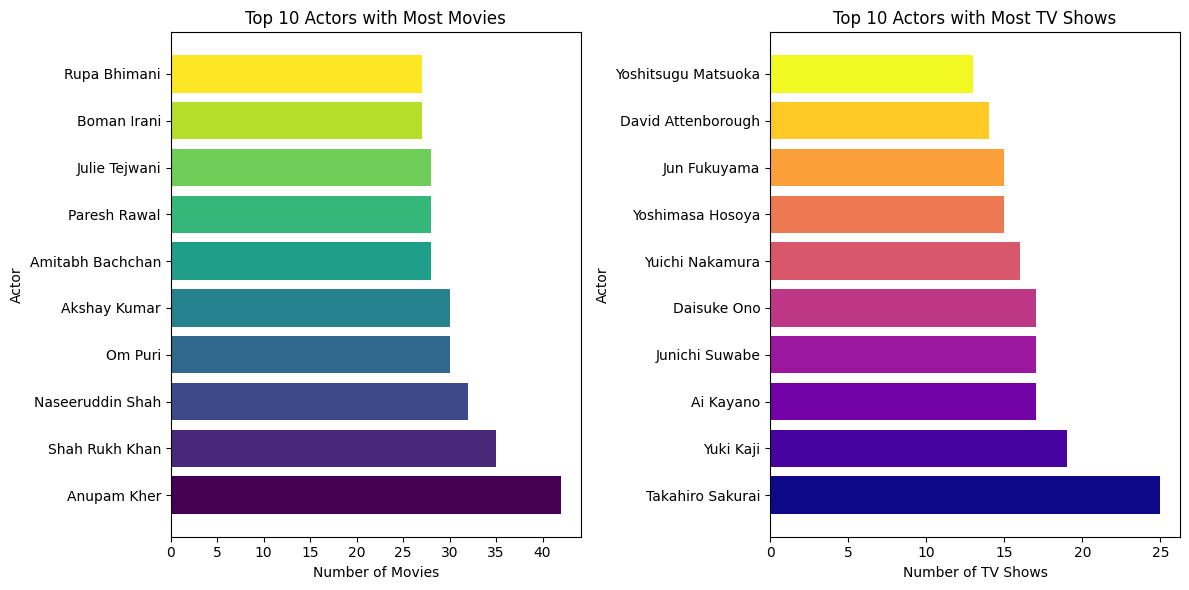

In [222]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Movies
colors1 = plt.cm.viridis(np.linspace(0, 1, len(top_10_actors_movies)))

# TV Shows
colors2 = plt.cm.plasma(np.linspace(0, 1, len(top_10_actors_tv_shows)))

# 🔹 Plot 1: Top Movie Actors
axs[0].barh(
    top_10_actors_movies['cast'],
    top_10_actors_movies['title'],
    color = colors1
)

axs[0].set_title('Top 10 Actors with Most Movies')
axs[0].set_xlabel('Number of Movies')
axs[0].set_ylabel('Actor')

# 🔹 Plot 2: Top TV Show Actors
axs[1].barh(
    top_10_actors_tv_shows['cast'],
    top_10_actors_tv_shows['title'],
    color=colors2
)
axs[1].set_title('Top 10 Actors with Most TV Shows')
axs[1].set_xlabel('Number of TV Shows')
axs[1].set_ylabel('Actor')

plt.tight_layout()
plt.savefig('./outputs/Top 10 Actors in Movies & TV Shows.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**

Based on the **bar plots** for **actors** , we can make the following observations.

* **Top 10 Actors with the Most Movies:** We can see that the actor **"Anupam Kher"** with the **most movie appearances** is shown at the top of the plot along with the color palette 'viridis' which is used to differentiate the bars of camparision with other actors.
* **Top 10 Actors with the Most TV Shows:** The actor **"Takahiro Sakurai"** with the **most TV show appearances** is shown at the top of the plot. The color palette 'magma' is used to differentiate the bars.

### **(Q8) Does Netflix has more focus on TV Shows than movies in recent years**

To determine if **Netflix** has **more focus on TV shows than movies in recent years**, we can analyze the trend of TV shows and movies added to the platform over time. We will group the data by the 'Type' (TV Show or Movie) and 'Year' to count the number of TV shows and movies added each year. Then, we will plot the results to visualize the trend.



In [223]:
df['Year'] = df['date_added'].dt.year

In [224]:
# Filter the dataset from TV shows and movies
tv_shows_df = df[df.type == 'TV Show']
movies_df = df[df.type == 'Movie']


In [225]:
# Count total number of tv shows and movies add each year
tv_shows_by_year = tv_shows_df.groupby('Year')['type'].count().reset_index()
movies_by_year = movies_df.groupby('Year')['type'].count().reset_index()

In [226]:
print(tv_shows_by_year)

     Year  type
0  2008.0     1
1  2013.0    48
2  2014.0    66
3  2015.0   238
4  2016.0  1791
5  2017.0  2878
6  2018.0  3365
7  2019.0  5100
8  2020.0  5754
9  2021.0  4726


In [227]:
print(movies_by_year)

      Year   type
0   2008.0      6
1   2009.0     18
2   2010.0     10
3   2011.0    200
4   2012.0     27
5   2013.0     33
6   2014.0    223
7   2015.0    675
8   2016.0   2295
9   2017.0   7970
10  2018.0  11950
11  2019.0  15420
12  2020.0  14844
13  2021.0  11675


In [228]:
#Merge the count of tv shows and movies into a single DataFrame
counts_by_year = pd.merge(tv_shows_by_year, movies_by_year, on='Year', how='outer')
counts_by_year.fillna(0, inplace=True)

,Year,type_x,type_y
0,2008.0,1.0,6
1,2009.0,0.0,18
2,2010.0,0.0,10
3,2011.0,0.0,200
4,2012.0,0.0,27
5,2013.0,48.0,33
6,2014.0,66.0,223
7,2015.0,238.0,675
8,2016.0,1791.0,2295
9,2017.0,2878.0,7970


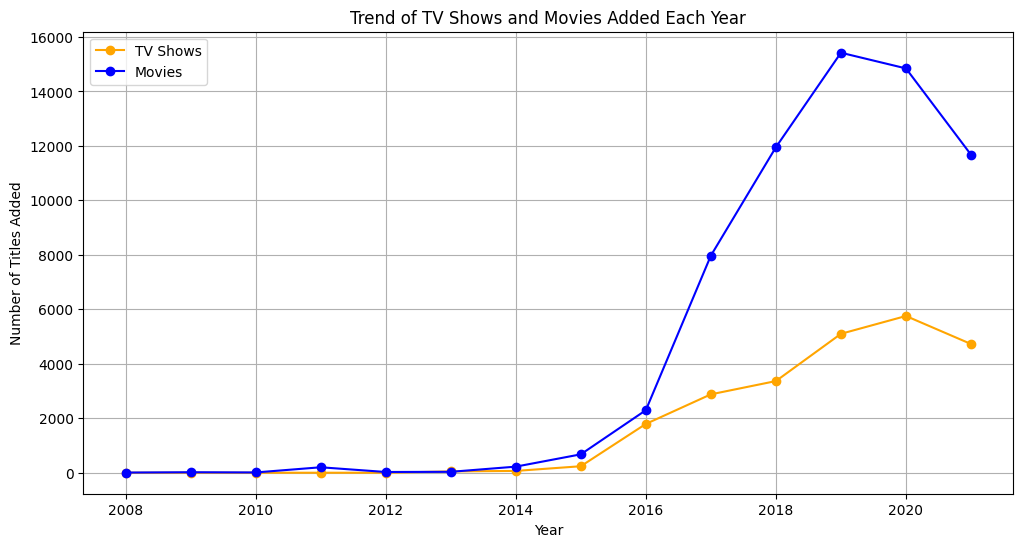

In [238]:
plt.figure(figsize=(12, 6))

# Ensure sorted
counts_by_year = counts_by_year.sort_values(by='Year')

# TV Shows
plt.plot(
    counts_by_year['Year'],
    counts_by_year['type_x'],
    marker='o',
    color='orange',
    label='TV Shows'
)

# Movies
plt.plot(
    counts_by_year['Year'],
    counts_by_year['type_y'],
    marker='o',
    color='blue',
    label='Movies'
)

plt.title('Trend of TV Shows and Movies Added Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.legend()
plt.grid(True)

plt.savefig('./outputs/Trend of TV Shows and Movies Added Each Year.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**

* The **blue & orange lines** represents the **trend of TV shows & Movies added each year**. The line plot shows how the number of TV shows & Movies added to **Netflix** has changed over time.
* By comparing the **trends of TV shows and movies**, we can observe if there has been a shift in **Netflix's focus** towards one type of content in recent years.

### **(Q9) Understanding what content is available in different countries**

To understand what content is available in different countries, we can analyze the dataset by grouping the data based on the 'Country' attribute and then count the number of TV shows and movies available in each country. This will give us insights into the distribution of content across different regions.


In [239]:
df['country'].value_counts()

country
United States      30471
India               8537
United Kingdom      5713
Unknown_country     5421
Canada              3946
                   ...  
Samoa                  1
Sri Lanka              1
Uganda                 1
United States,         1
Vatican City           1
Name: count, Length: 128, dtype: int64

In [240]:
df['title'].value_counts()

title
Movie 43                           468
Kahlil Gibran's The Prophet        350
Holidays                           252
The Eddy                           208
Navarasa                           198
                                  ... 
Women Behind Bars                    1
Woodstock                            1
World's Weirdest Homes               1
WWII: Report from the Aleutians      1
Zombie Dumb                          1
Name: count, Length: 8807, dtype: int64

In [242]:
content_by_country = df.groupby('country')['title'].nunique().reset_index()
content_by_country

,country,title
0,,2
1,Afghanistan,1
2,Albania,1
3,Algeria,3
4,Angola,1
...,...,...
123,Vatican City,1
124,Venezuela,4
125,Vietnam,7
126,West Germany,5


In [243]:
# Sorting the data in descending order of content availability
content_by_country = content_by_country.sort_values(by='title', ascending=False)
content_by_country

,country,title
119,United States,3689
47,India,1046
121,Unknown_country,831
117,United Kingdom,804
22,Canada,445
...,...,...
101,Somalia,1
106,Sri Lanka,1
114,Uganda,1
123,Vatican City,1


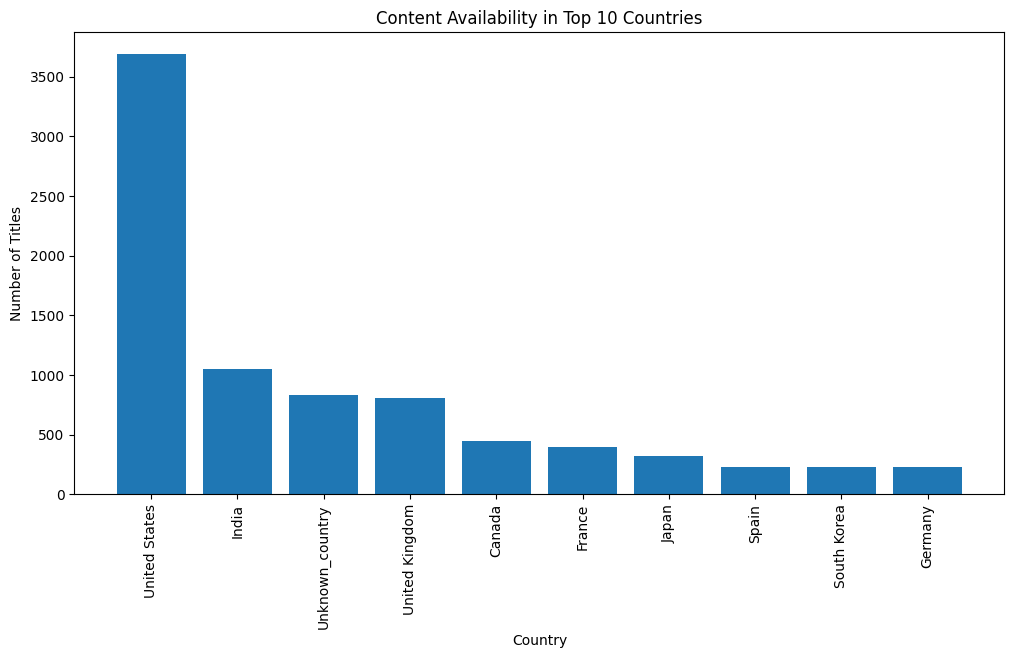

In [247]:
# Plotting the top 10 countries with the most content (bar plot)
plt.figure(figsize=(12, 6))
plt.bar(content_by_country['country'][:10], content_by_country['title'][:10])

plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Content Availability in Top 10 Countries')

plt.xticks(rotation=90)
plt.show()

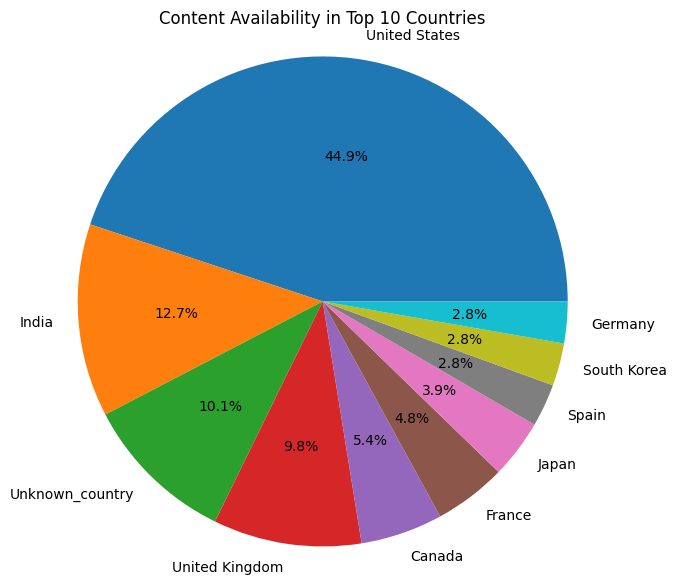

In [250]:
# Plotting the top 10 countries with the most content (pie chart)
plt.figure(figsize=(8, 7))
plt.pie(content_by_country['title'][:10], labels=content_by_country['country'][:10], autopct='%1.1f%%')
plt.title('Content Availability in Top 10 Countries')
plt.axis('equal')

plt.savefig('./outputs/Content Availability in Top 10 Countries.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:**

* The **bar plot** displays the **number of titles** available in the **top 10 countries** with the **most content**. Each bar represents a country, and its height represents the number of unique titles available in that country.
* The **pie chart** illustrates the **distribution of content** availability among the **top 10 countries**. Each slice represents a country, and its size corresponds to the proportion of content available in that country relative to the total content in the top 10 countries.

### **(Q10) Which genre movies are more popular or produced more**

**`Hint:`** We want you to apply the **word cloud** on the **genre** columns to know which kind of **genre** is produced

To identify which **genre** of **movies** is **more popular or produced mor**e, we can create a **word cloud** to visualize the frequency of different genres in the dataset. A **word cloud** is a **graphical representation of word frequencies, where the size of each word corresponds to its frequency** in the dataset.



In [252]:
from wordcloud import WordCloud

In [253]:
# Combine all the genres into a single string
all_genres = ' '.join(df['listed_in'])

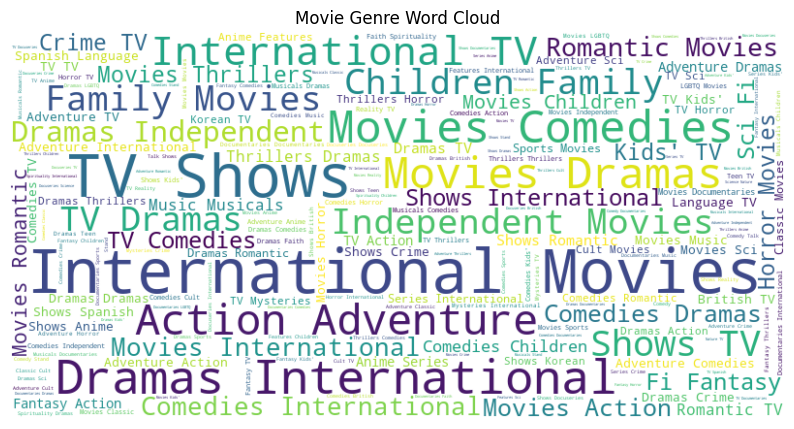

In [255]:
# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_genres)

# Plot the WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Movie Genre Word Cloud')
plt.axis('off')

plt.savefig('./outputs/Movie Genre Word Cloud.png', dpi=300, bbox_inches='tight')

plt.show()

**Observation:**

* The provided code creates a **word cloud** visualization based on the **movie genres** available in the **Netflix** dataset. A **word cloud** here represents the **popularity or frequency of different movie genres**.